# Iris Flower Classification

## Objective

The aim is to classify iris flowers among three species from measurements of sepals and petals length and width.The iris dataset contains 3 classes of 50 instances each, where each class refers to a type of iris plant.The central goal here is to design a model that makes useful classifications for new flowers or, in other words, one which exhibits good generalization.

### Importing libraries

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
import os
data_file = "data/iris_data.csv"
if not os.path.exists(data_file):
    data_file = "../data/iris_data.csv"
samp_dataset = pd.read_csv(data_file)
samp_dataset

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
columns=["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm","Species"]
import os
data_file = "data/iris_data.csv"
if not os.path.exists(data_file):
    data_file = "../data/iris_data.csv"
dataset = pd.read_csv(data_file,names=columns,header=0)
dataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
dataset.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [6]:
dataset.shape

(150, 5)

## Exploratory Data Analysis(EDA)

**Histogram of Petal Length**

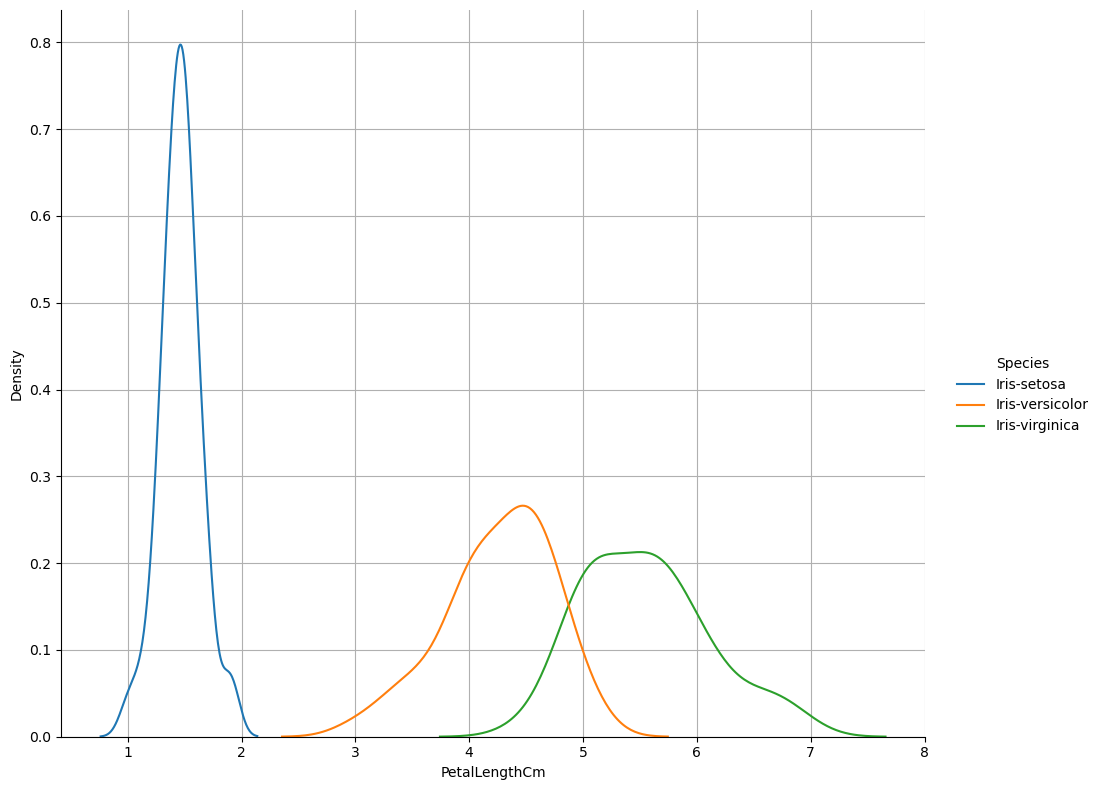

In [7]:

sns.displot(data=dataset, x="PetalLengthCm", hue="Species", kind="kde", height=8, aspect=1.2)
plt.grid(True)
plt.show()


**Histogram of Petal Width**

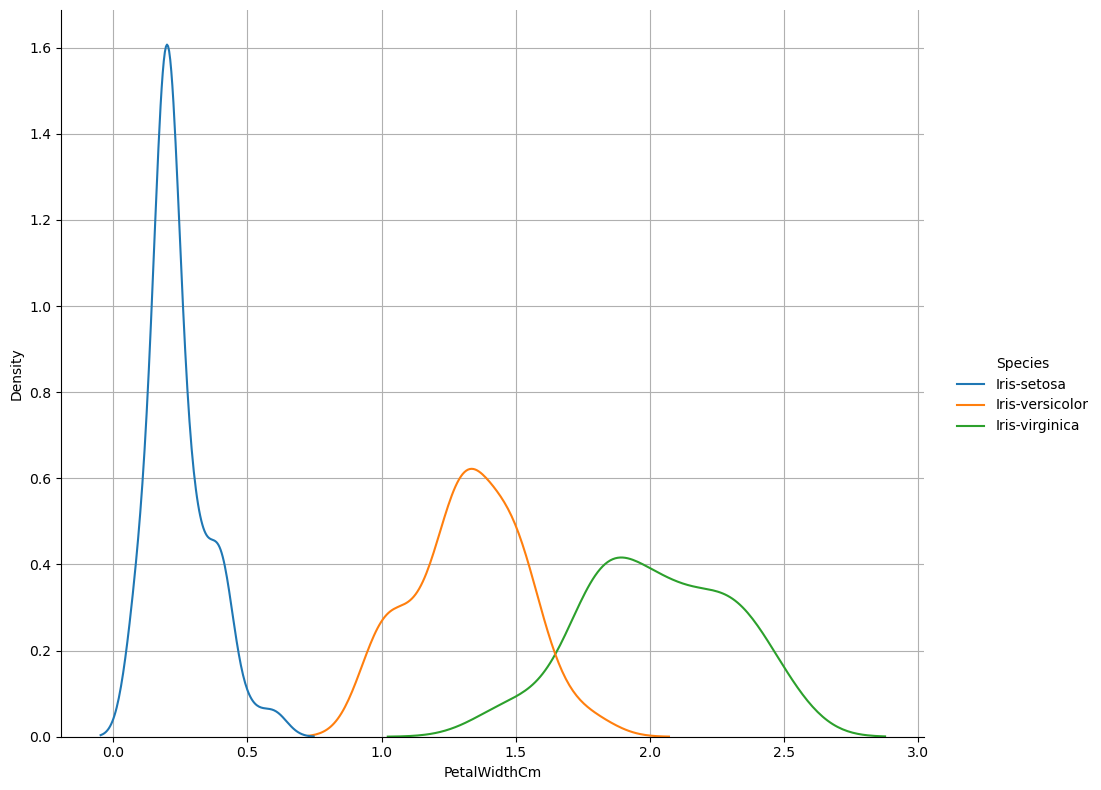

In [8]:
sns.displot(data=dataset, x="PetalWidthCm", hue="Species", kind="kde", height=8, aspect=1.2)
plt.grid(True)
plt.show()

**Histogram of Sepal Length**

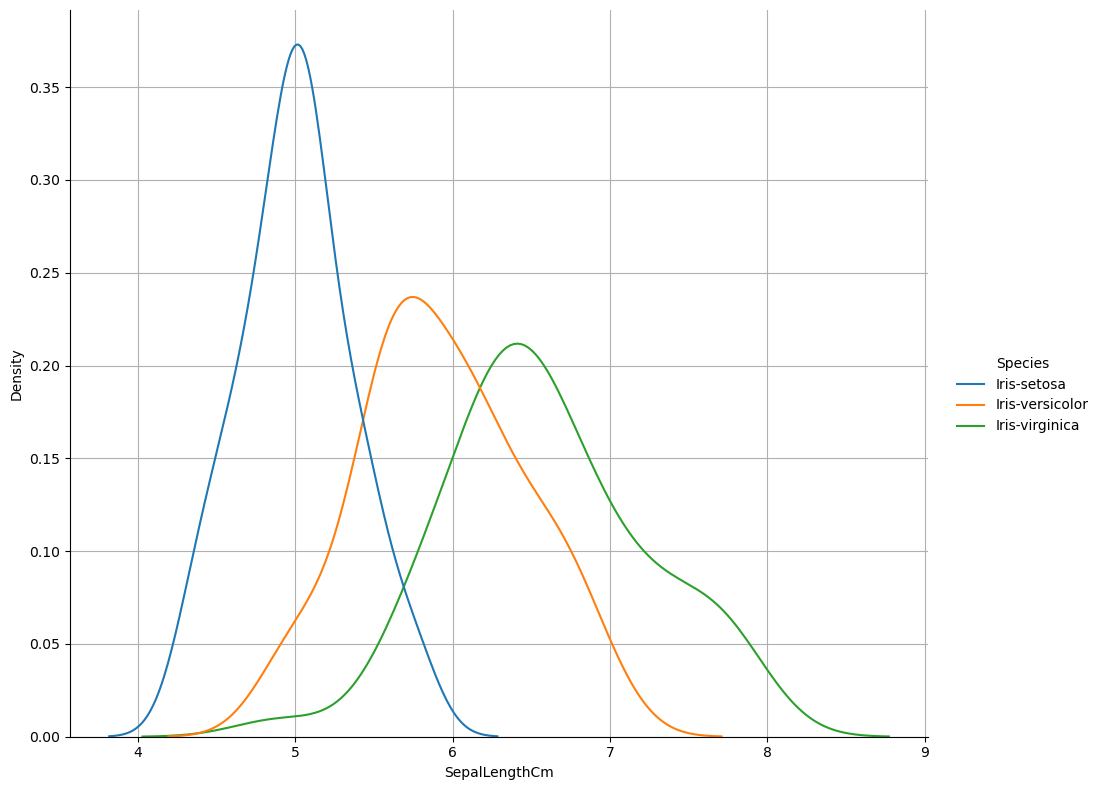

In [9]:
sns.displot(data=dataset, x="SepalLengthCm", hue="Species", kind="kde", height=8, aspect=1.2)
plt.grid(True)
plt.show()

**Histogram of Sepal Width**

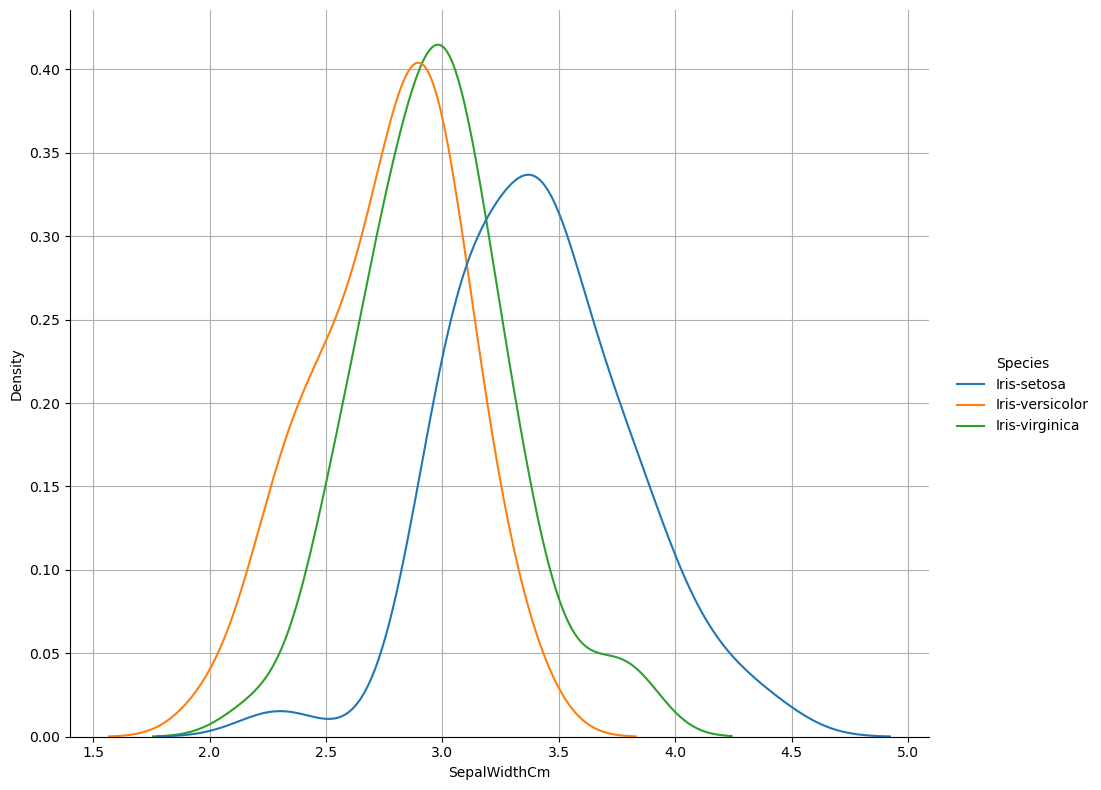

In [10]:
sns.displot(data=dataset, x="SepalWidthCm", hue="Species", kind="kde", height=8, aspect=1.2)
plt.grid(True)
plt.show()

**2D Scatter Plot**

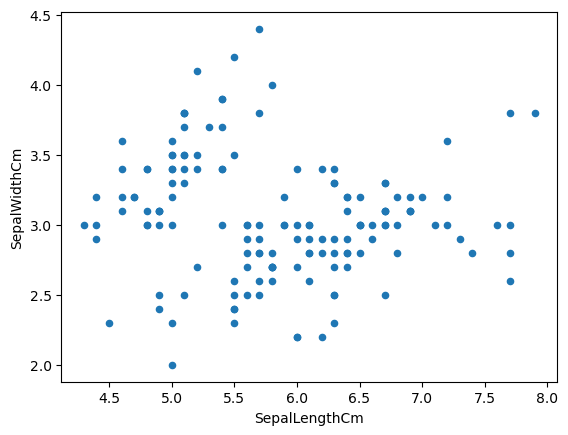

In [11]:
dataset.plot(kind="scatter", x="SepalLengthCm", y="SepalWidthCm")
plt.show()

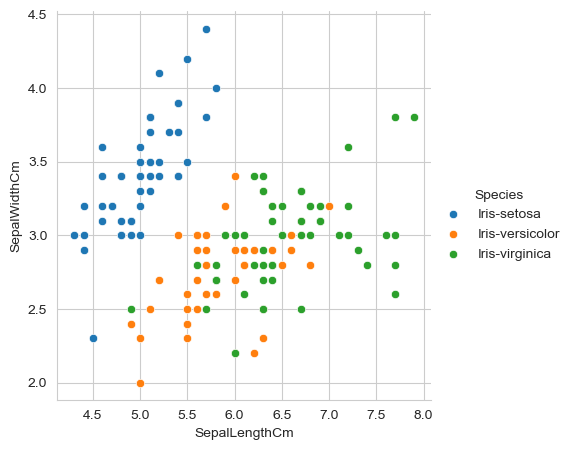

In [12]:
sns.set_style("whitegrid")
gr=sns.FacetGrid(dataset, hue="Species", height=4.6)
gr.map_dataframe(sns.scatterplot, x="SepalLengthCm", y="SepalWidthCm")
gr.add_legend()
plt.show()

**Pair-wise Scatter Plot**

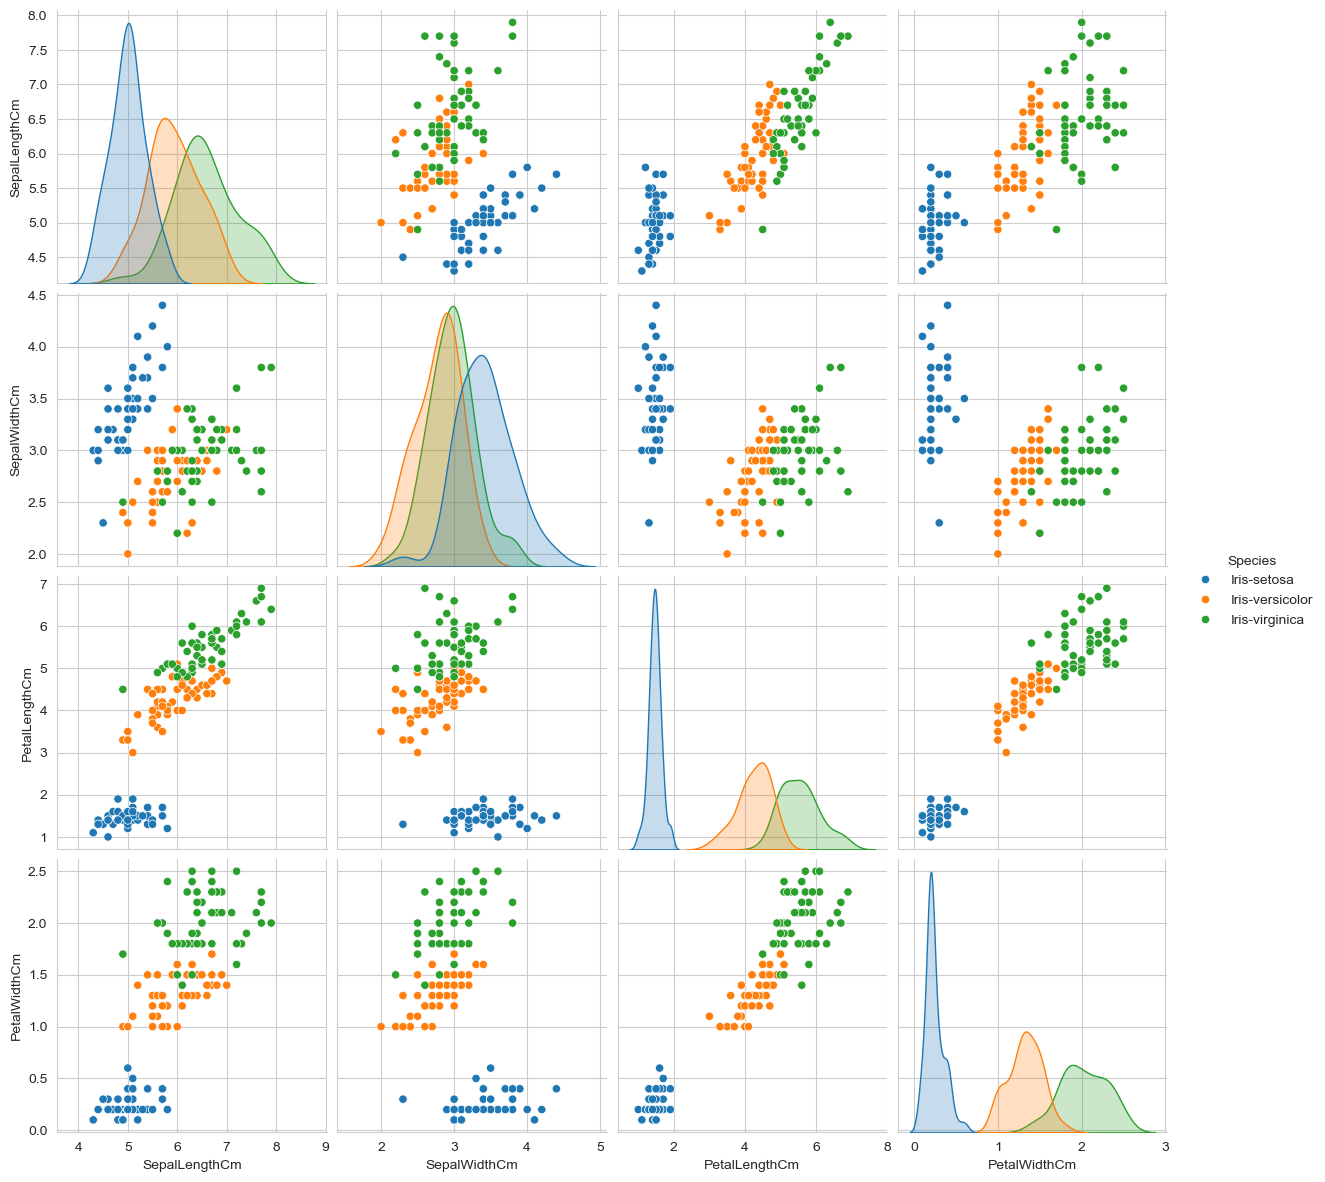

In [13]:
sns.set_style("whitegrid")
sns.pairplot(dataset, hue="Species", height=3, aspect=1)
plt.show()

## Data Preprocessing

In [14]:
dataset["Species"].value_counts()


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [15]:
dataset.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


**Descriptive Statistics of Dataset**

In [16]:
dataset.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Checking for Null Values**

In [17]:
dataset.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [18]:
dataset["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

**Label Encoding**

In [19]:
label_encoder=preprocessing.LabelEncoder()
dataset["Species"] = label_encoder.fit_transform(dataset["Species"])

dataset["Species"].unique()

array([0, 1, 2])

**Splitting the Data**

In [20]:
X = dataset.iloc[:, [2,3]].values

y = dataset.iloc[:, 4].values

In [21]:
len(X)

150

In [22]:
len(y)

150

**HeatMap - To identify Highly Correlated Features**

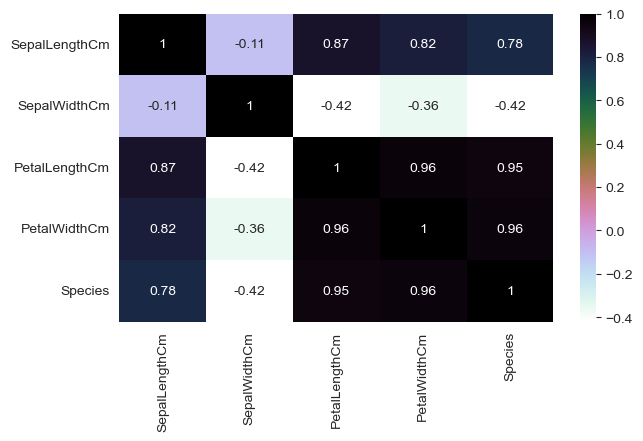

In [23]:
plt.figure(figsize=(7,4))
sns.heatmap(dataset.corr(), annot=True, cmap="cubehelix_r")
plt.show()

## Model Development

**Splitting the Dataset into Train-Set and Test-Set**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2)


**Feature Scaling**

In [25]:
sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

### Decision Tree Classifier 

In [26]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


***Predicting the Results***

In [27]:
y_pred = classifier.predict(X_test)

***confusion matrix***

In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[17,  0,  0],
       [ 0, 14,  1],
       [ 0,  2, 11]])

***Visualising the Training set results***

C:\Users\rez\AppData\Local\Temp\ipykernel_10812\4133020138.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


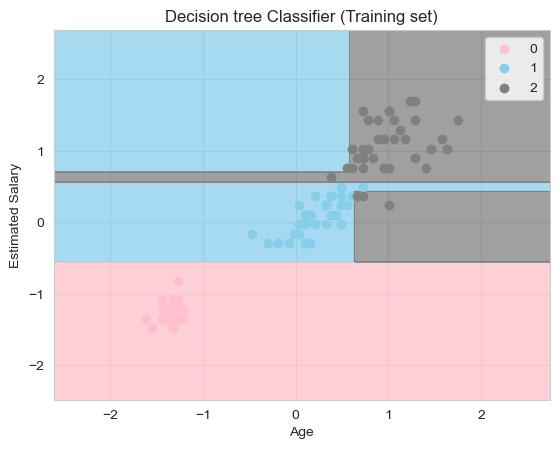

In [29]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('pink','skyblue','gray')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('pink', 'skyblue','gray'))(i), label = j)
plt.title('Decision tree Classifier (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

***Visualising the Test set results***

C:\Users\rez\AppData\Local\Temp\ipykernel_10812\474813364.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


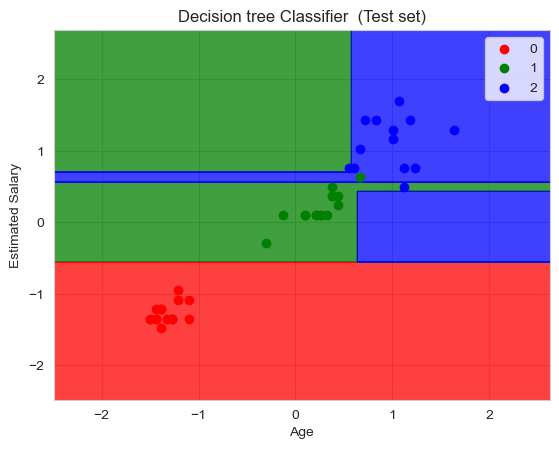

In [30]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green','blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green','blue'))(i), label = j)
plt.title('Decision tree Classifier  (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from math import sqrt
print('The accuracy of the Decision Tree Classifier is : %.2f'%accuracy_score(y_pred,y_test))
rmse = sqrt(mean_squared_error(y_test, y_pred))
print("RMSE value = %.2f"%rmse)
print("R2 Score= %.2f"%r2_score(y_test, y_pred))

The accuracy of the Decision Tree Classifier is : 0.93
RMSE value = 0.26
R2 Score= 0.90


In [32]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        17\n           1       0.88      0.93      0.90        15\n           2       0.92      0.85      0.88        13\n\n    accuracy                           0.93        45\n   macro avg       0.93      0.93      0.93        45\nweighted avg       0.93      0.93      0.93        45\n'

## KNN Algorithm

In [33]:
from sklearn import neighbors
model = neighbors.KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
predict = model.predict(X_test)

In [35]:
#for checking the model accuracy
print('The accuracy of the KNN is',accuracy_score(predict,y_test))
rmse = sqrt(mean_squared_error(y_test, predict))
print("RMSE value = %.2f"%rmse)
print("R2 Score= %.2f"%r2_score(y_test, predict))

The accuracy of the KNN is 0.9777777777777777
RMSE value = 0.15
R2 Score= 0.97


## SVM ##

In [36]:
from sklearn import svm
svc = svm.SVC(C=1.0, kernel='rbf')

In [37]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
pred = svc.predict(X_test)

In [39]:
#Accuracy 

print('The accuracy of the SVM is: %.2f'%accuracy_score(pred,y_test))
rmse = sqrt(mean_squared_error(y_test, pred))
print("RMSE value = %.2f"%rmse)
print("R2 Score= %.2f"%r2_score(y_test, pred))

The accuracy of the SVM is: 0.98
RMSE value = 0.15
R2 Score= 0.97


## Logistic Regression ##

In [40]:
from sklearn.linear_model import LogisticRegression # for Logistic Regression algorithm
model = LogisticRegression()
model.fit(X_train,y_train) 
prediction=model.predict(X_test) 

In [41]:
print('The accuracy of the Logistic Regression using Petals is:',accuracy_score(prediction,y_test))
rmse = sqrt(mean_squared_error(y_test, prediction))
print("RMSE value = %.2f"%rmse)
print("R2 Score= %.2f"%r2_score(y_test, prediction))

The accuracy of the Logistic Regression using Petals is: 0.9777777777777777
RMSE value = 0.15
R2 Score= 0.97


## Naive Bayes ##

In [42]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train,y_train) 
predicted= model.predict(X_test) 
store_results("GuassianNB", y_test, y_pred)

In [43]:
print('The accuracy of the naive_bayes is:',accuracy_score(predicted,y_test))
rmse = sqrt(mean_squared_error(y_test, predicted))
print("RMSE value = %.2f"%rmse)
print("R2 Score= %.2f"%r2_score(y_test, predicted))

The accuracy of the naive_bayes is: 0.9777777777777777
RMSE value = 0.15
R2 Score= 0.97
